In [13]:
# MOVIE-SENTIBOT: Model 3 - Naive Bayes with Full EDA and Comparative Analysis

# Step 1: Import Necessary Libraries
print("Step 1: Importing libraries...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import joblib
from wordcloud import WordCloud
import time

# Set plot style
sns.set_style('whitegrid')
print("Libraries imported successfully.\n")

Step 1: Importing libraries...
Libraries imported successfully.



In [14]:
# Step 2: Mount Google Drive and Load Data
print("Step 2: Loading preprocessed data from Google Drive...")
try:
    if not os.path.isdir('/content/drive/My Drive'):
        drive.mount('/content/drive')

    # --- IMPORTANT ---
    # Update this path to your preprocessed CSV file in Google Drive.
    file_path = '/content/drive/MyDrive/AIML assignment/results/preprocessed_reviews.csv'

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found at '{file_path}'. Please check the path.")

    df = pd.read_csv(file_path)
    df.dropna(subset=['review', 'sentiment'], inplace=True)

    print("Dataset loaded successfully.")
    print("\nDataset Head:")
    print(df.head())
except Exception as e:
    print(f"An error occurred: {e}")



Step 2: Loading preprocessed data from Google Drive...
Dataset loaded successfully.

Dataset Head:
                                              review  sentiment
0  one review mention watch oz episod hook right ...          1
1  wonder littl product film techniqu unassum old...          1
2  thought wonder way spend time hot summer weeke...          1
3  basic famili littl boy jake think zombi closet...          0
4  petter mattei love time money visual stun film...          1



Step 3: Performing Exploratory Data Analysis (EDA)...


/tmp/ipython-input-4201286636.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


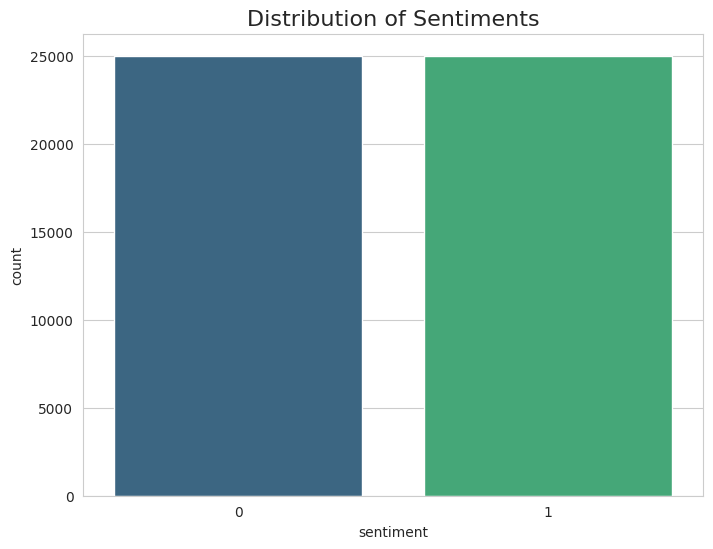


Generating Word Cloud...


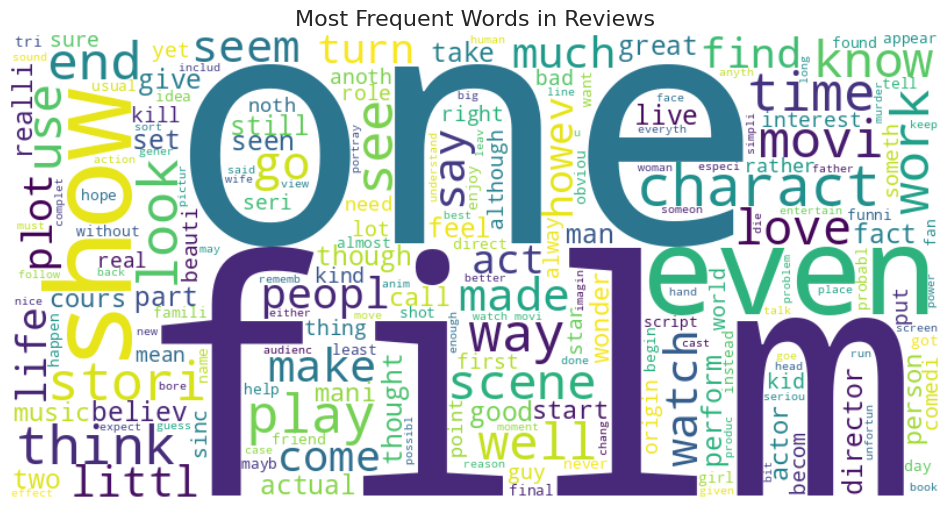

In [15]:
# Step 3: Exploratory Data Analysis (EDA)
print("\nStep 3: Performing Exploratory Data Analysis (EDA)...")

# EDA 1: Sentiment Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiments', fontsize=16)
plt.show()

# EDA 2: Word Cloud
print("\nGenerating Word Cloud...")
all_reviews = ' '.join(df['review'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_reviews)
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Reviews', fontsize=16)
plt.show()

In [16]:
# Step 4: Data Splitting
print("\nStep 4: Splitting data...")
X = df['review']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples\n")



Step 4: Splitting data...
Training set size: 40000 samples
Testing set size: 10000 samples



Step 5: Training and evaluating a baseline Naive Bayes model...

Baseline Model Accuracy: 0.8622 (86.22%)

Baseline Model Confusion Matrix:


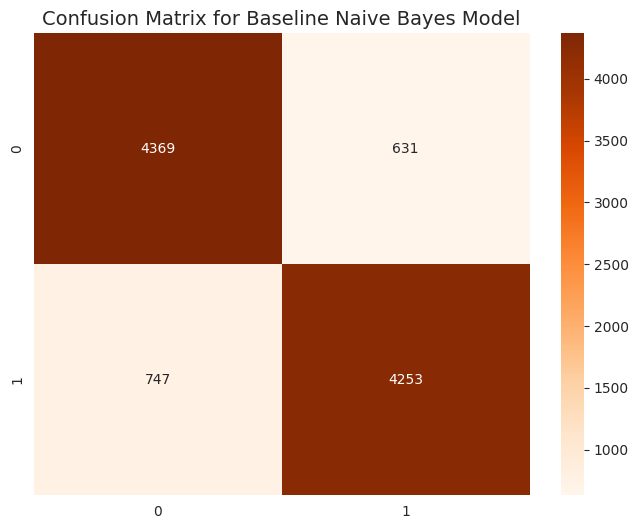

In [17]:
# Step 5: Baseline Model (Before Tuning)
print("Step 5: Training and evaluating a baseline Naive Bayes model...")
baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB())
])
baseline_pipeline.fit(X_train, y_train)
y_pred_baseline = baseline_pipeline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"\nBaseline Model Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy:.2%})")

print("\nBaseline Model Confusion Matrix:")
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix for Baseline Naive Bayes Model', fontsize=14)
plt.show()


In [18]:
# Step 6: Hyperparameter Tuning with GridSearchCV
print("\nStep 6: Performing hyperparameter tuning with a pipeline...")
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB())
])

# Tune 3 hyperparameters: 2 from the classifier and 1 from the vectorizer
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__alpha': [0.1, 0.5, 1.0],
    'clf__fit_prior': [True, False]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=2, scoring='accuracy')

start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()

print(f"\nGridSearchCV completed in {end_time - start_time:.2f} seconds.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

print("\n--- Hyperparameter Tuning Results ---")
cv_results_df = pd.DataFrame(grid_search.cv_results_)
for i, params in enumerate(cv_results_df['params']):
    print(f"\nTuning {i+1}: {params}")
    print(f"Mean CV Accuracy: {cv_results_df['mean_test_score'][i]:.4f}")


Step 6: Performing hyperparameter tuning with a pipeline...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

GridSearchCV completed in 607.68 seconds.
Best parameters found: {'clf__alpha': 0.5, 'clf__fit_prior': True, 'tfidf__ngram_range': (1, 2)}
Best cross-validation accuracy: 0.8849

--- Hyperparameter Tuning Results ---

Tuning 1: {'clf__alpha': 0.1, 'clf__fit_prior': True, 'tfidf__ngram_range': (1, 1)}
Mean CV Accuracy: 0.8528

Tuning 2: {'clf__alpha': 0.1, 'clf__fit_prior': True, 'tfidf__ngram_range': (1, 2)}
Mean CV Accuracy: 0.8846

Tuning 3: {'clf__alpha': 0.1, 'clf__fit_prior': False, 'tfidf__ngram_range': (1, 1)}
Mean CV Accuracy: 0.8528

Tuning 4: {'clf__alpha': 0.1, 'clf__fit_prior': False, 'tfidf__ngram_range': (1, 2)}
Mean CV Accuracy: 0.8846

Tuning 5: {'clf__alpha': 0.5, 'clf__fit_prior': True, 'tfidf__ngram_range': (1, 1)}
Mean CV Accuracy: 0.8559

Tuning 6: {'clf__alpha': 0.5, 'clf__fit_prior': True, 'tfidf__ngram_range': (1, 2)}
Mean CV Accuracy: 0.884


Step 7: Evaluating the final tuned model...

Final Tuned Model Accuracy: 0.8874 (88.74%)

Final Model Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89      5000
    Positive       0.89      0.88      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Final Model Confusion Matrix:


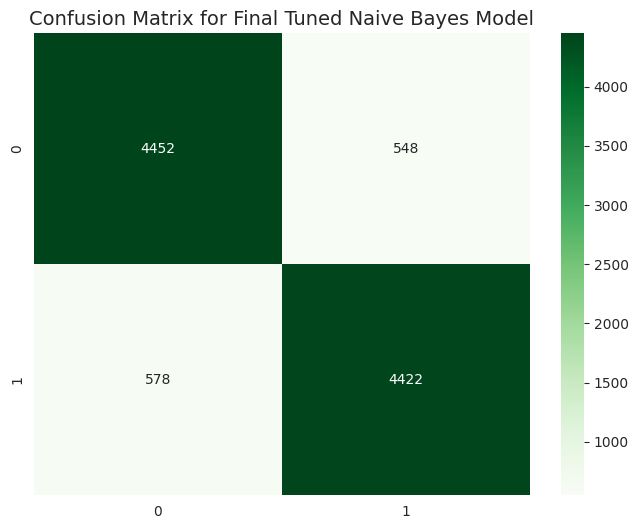

In [19]:
# Step 7: Final Model Evaluation (After Tuning)
print("\nStep 7: Evaluating the final tuned model...")
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"\nFinal Tuned Model Accuracy: {final_accuracy:.4f} ({final_accuracy:.2%})")

print("\nFinal Model Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Negative', 'Positive']))

print("\nFinal Model Confusion Matrix:")
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix for Final Tuned Naive Bayes Model', fontsize=14)
plt.show()



Step 8: Visualizing comparison of model performances...


/tmp/ipython-input-2201734067.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='coolwarm')


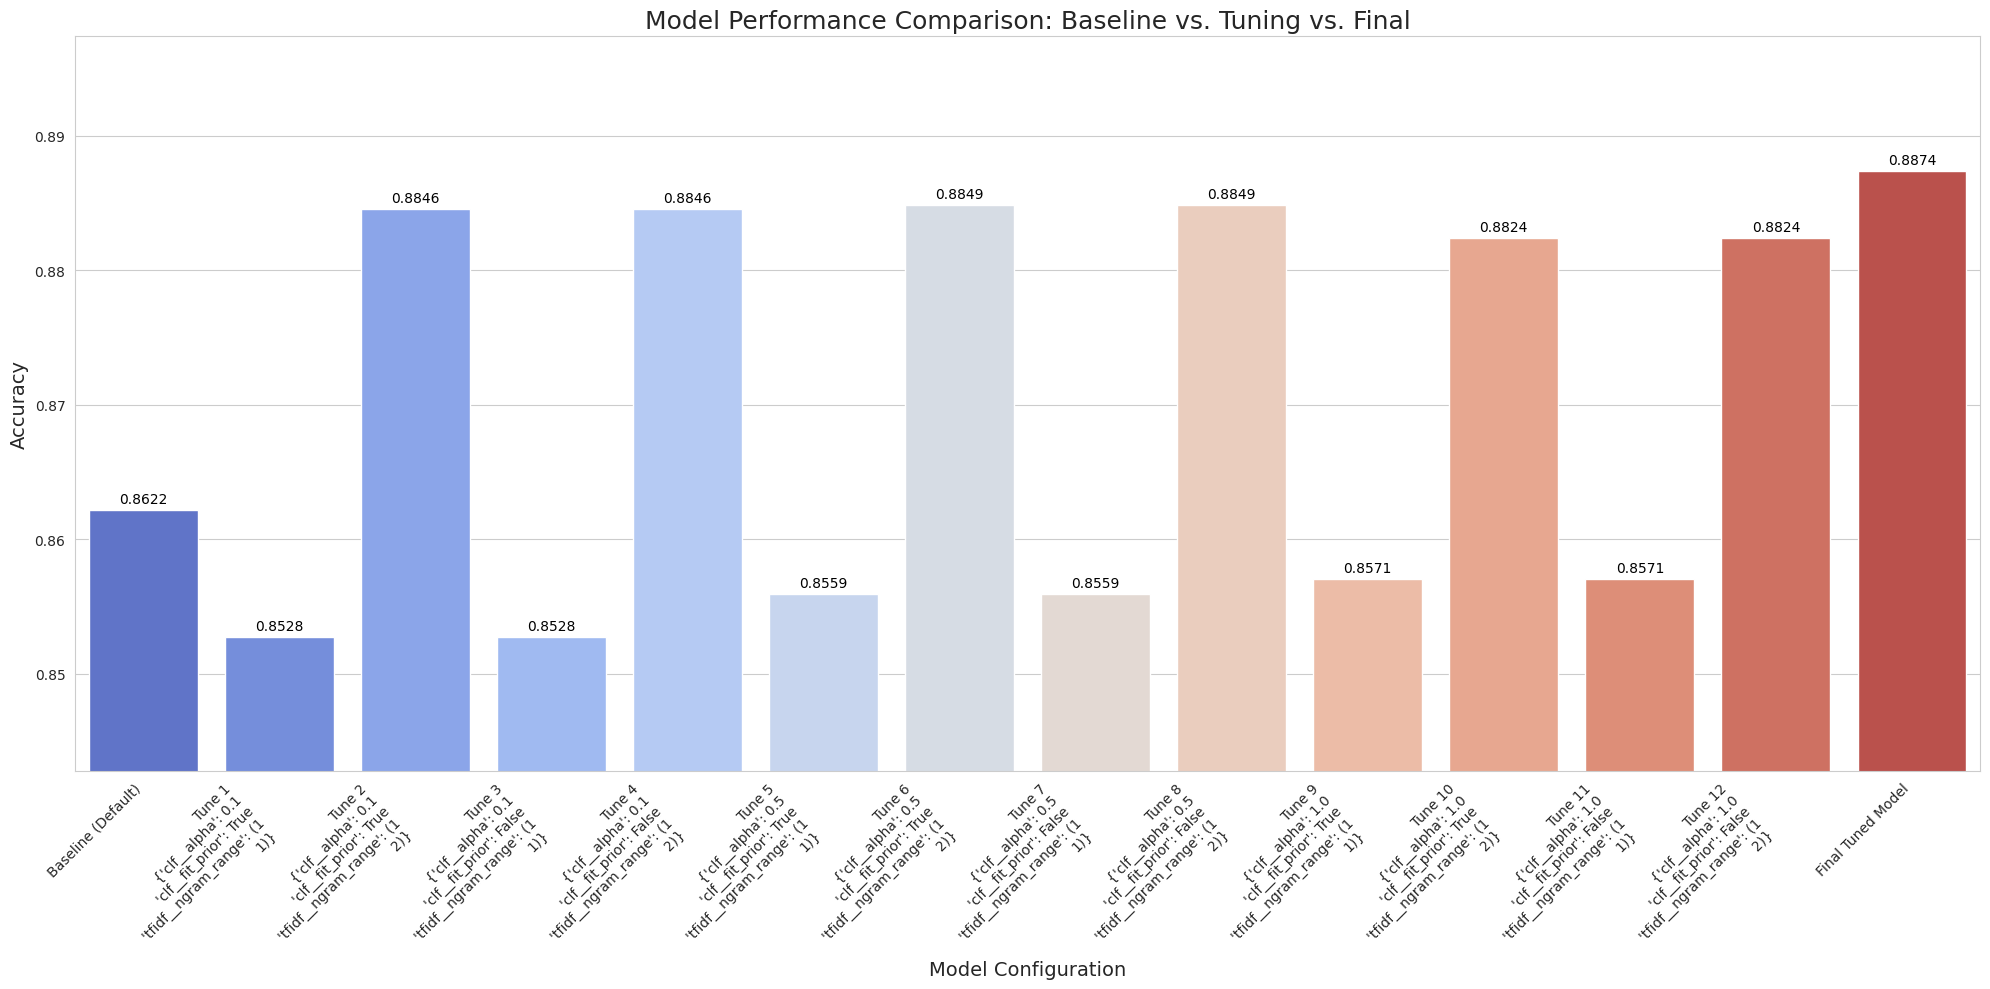

In [20]:
# Step 8: Comparative Visualization
print("\nStep 8: Visualizing comparison of model performances...")
model_names = [f"Tune {i+1}\n{str(p).replace(', ', '\n')}" for i, p in enumerate(cv_results_df['params'])]
accuracies = cv_results_df['mean_test_score']

comparison_data = {
    'Model': ['Baseline (Default)'] + model_names + ['Final Tuned Model'],
    'Accuracy': [baseline_accuracy] + list(accuracies) + [final_accuracy]
}
comparison_df = pd.DataFrame(comparison_data)

plt.figure(figsize=(20, 10))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='coolwarm')
plt.title('Model Performance Comparison: Baseline vs. Tuning vs. Final', fontsize=18)
plt.ylabel('Accuracy', fontsize=14)
plt.xlabel('Model Configuration', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(min(comparison_df['Accuracy']) - 0.01, max(comparison_df['Accuracy']) + 0.01)
for index, row in comparison_df.iterrows():
    plt.text(index, row.Accuracy + 0.0005, f'{row.Accuracy:.4f}', color='black', ha="center")
plt.tight_layout()
plt.show()


In [21]:
# Step 9: Save the Model and Results
print("\nStep 9: Saving the model pipeline and results...")
results_dir = '/content/drive/MyDrive/AIML assignment/results/naive_bayes_results'
os.makedirs(results_dir, exist_ok=True)

# Save model pipeline
joblib.dump(best_model, os.path.join(results_dir, 'naive_bayes_pipeline.pkl'))

# Save reports
report_df = pd.DataFrame(classification_report(y_test, y_pred_final, output_dict=True)).transpose()
report_df.to_csv(os.path.join(results_dir, 'classification_report.csv'))
comparison_df.to_csv(os.path.join(results_dir, 'performance_comparison.csv'))

with open(os.path.join(results_dir, 'accuracy.txt'), 'w') as f:
    f.write(f'Baseline Model Accuracy: {baseline_accuracy:.4f}\n')
    f.write(f'Final Tuned Model Accuracy: {final_accuracy:.4f}\n')

print(f"\nAll results and the final model pipeline have been saved to {results_dir}")


Step 9: Saving the model pipeline and results...

All results and the final model pipeline have been saved to /content/drive/MyDrive/AIML assignment/results/naive_bayes_results
